# 🧠 Explore the data — HCP N-back working memory (Finalist B, 339 subjects)

**Author(s):** Jaime (shared data layer) · style aligned with Goutham's POC 
**Date:** 2026-07-15
**Status:** exploratory / for team review — first shared `pipeline/` notebook

**Question** *how do I get from a raw brain recording to the two inputs the project needs — a **functional-connectivity matrix
per load condition** and a **per-subject working-memory score** — without re-writing any loaders?*

**Who it's for.** B dataset and the 0-back → 2-back reconfiguration signal that the whole pipeline is built to predict.

> This mirrors the analysis Goutham prototyped (FC per condition → `2bk − 0bk` reconfiguration →
> triple-network view → prediction), but on the **shared A/B layer** and on **B (339 subjects)**

## 0 · Setup — find the repo, wire the shared layer, point at the data

The cell below is the **same setup cell as the notebook template**. It finds the repo root from
wherever you run it (repo root, your `sandbox/<name>/`, or Colab), puts the shared A/B data layer
on the path, and sets the data directory.

**Prerequisites:** `pip install -r requirements.txt` and the data downloaded — see
[`data/README.md`](../data/README.md). You do **not** need to download all 8 GB to read this
notebook: the outputs below are already rendered on GitHub.

In [16]:
# --- Setup: find the repo root, add the shared A/B data layer, set the data dir ---
# Runs from the repo root, your sandbox/<name>/ folder, or Colab.

# Colab only — uncomment to fetch the code (data is separate; see ../data/README.md):
# !git clone -q https://github.com/The-Gammas/The-Gammas.git
# %cd The-Gammas
# !pip install -q -r requirements.txt

import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def find_repo_root(start: Path) -> Path:
    # Nearest ancestor holding requirements.txt and sandbox/ — the repo root (same as the template).
    for p in (start, *start.parents):
        if (p / "requirements.txt").exists() and (p / "sandbox").is_dir():
            return p
    raise FileNotFoundError("Repo root not found — run this inside a clone of The-Gammas.")


ROOT = find_repo_root(Path.cwd())
SHARED = ROOT / "sandbox" / "jaime"        # shared A/B loader layer — import read-only
sys.path.insert(0, str(SHARED))            # first on the path, so `import datasets` is ours
DATA = Path(os.environ.get("GAMMAS_DATA_DIR", ROOT / "data"))   # override if your data live elsewhere

import datasets as ds, preprocessing as pp, evaluation as ev

sns.set_theme(style="whitegrid", context="notebook")
%config InlineBackend.figure_format = "retina"

print("repo :", ROOT.name)
print("data :", DATA)
print("layer:", SHARED.name, "→ datasets / preprocessing / evaluation")

repo : the-gammas
data : /Users/jaimepm/Library/Mobile Documents/com~apple~CloudDocs/Wiki/Life Long Learning/NeuroAcademy/project/fmri/the-gammas/data
layer: jaime → datasets / preprocessing / evaluation


## 1 · The 30-second mental model

Before any code, the picture to hold in your head:

**Subjects.** 
- ~339 healthy adults did a **working-memory (N-back)** task in the scanner.
- In Finalist B they carry **pseudo-IDs** (`0…338`) — de-identified, safe to show. 
- 336 have a usable
  2-back score (three are dropped for incomplete behaviour).

**The brain, as 360 numbers** 
- Each brain is summarised as **360 cortical regions** (ROIs, the*Glasser* parcellation). 
- Each ROI is assigned to **one of 12 functional networks** (*Cole–Anticevic*) 
- e.g. Frontoparietal, Default, Cingulo-Opercular (salience).


**The signal.** For every ROI we have a **BOLD time series**: one number per ROI per *frame*
  (a frame = one whole-brain snapshot every **0.72 s**). A WM run is ≈ 405 frames.

**Two loads.** The task alternates **0-back** (easy: "match a fixed target") and **2-back**
  (hard: "match the image 2 back" — real working memory). We split the frames into these two
  conditions using the timing (EV) files.

**What the project wants.** (a) A **functional-connectivity (FC) matrix per condition** — how
  synchronised each pair of ROIs is — and (b) a **behavioural score** per subject to predict.
  The hypothesis: connectivity **reconfigures** from 0-back to 2-back, and *how much* it
  reconfigures predicts *how well* someone performs.

Everything below turns that paragraph into objects you can load in two lines.

## 2 · Load it — one interface, `spec_b` vs `spec_a`

The whole dataset sits behind **one** object, the `DatasetSpec`. You pick the finalist with
`ds.spec_b` (339) or `ds.spec_a` (100); **nothing downstream changes**. We use B here.

In [17]:
spec = ds.spec_b(DATA)                 # ← the only A/B switch in the whole pipeline
subjects = ds.load_subjects(spec)      # analytic cohort (drops 3 subjects w/o complete 2-back)

print(spec.name)
print("loader        :", spec.loader)
print("analytic subj :", len(subjects), "  (pseudo-IDs, e.g.", subjects[:6], "…)")
print("task dir       :", spec.task_dir.name)
print("has rest?      :", spec.rest_dir is not None, " | has atlas?", spec.atlas is not None)

Finalist B (339 subj, +resting-state)
loader        : load_hcp
analytic subj : 336   (pseudo-IDs, e.g. ['0', '1', '2', '3', '4', '5'] …)
task dir       : hcp_task_339
has rest?      : True  | has atlas? True


## 3 · The objects, defined

This is the *data dictionary in action* — every object you'll import, with its shape. Full
reference: [`docs/data-dictionary.md`](../docs/data-dictionary.md).

### 3.1 · Regions and networks — the 360 ROIs

`pp.region_table(spec)` returns one row per ROI: its name, hemisphere, and de-truncated network.

In [4]:
regions = pp.region_table(spec)
print("region_table:", regions.shape, "→ one row per ROI")
regions.head()

region_table: (360, 5) → one row per ROI


,roi_index,name,network_raw,hemi,network
0,0,R_V1,Visual1,Right,Visual1
1,1,R_MST,Visual2,Right,Visual2
2,2,R_V6,Visual2,Right,Visual2
3,3,R_V2,Visual2,Right,Visual2
4,4,R_V3,Visual2,Right,Visual2


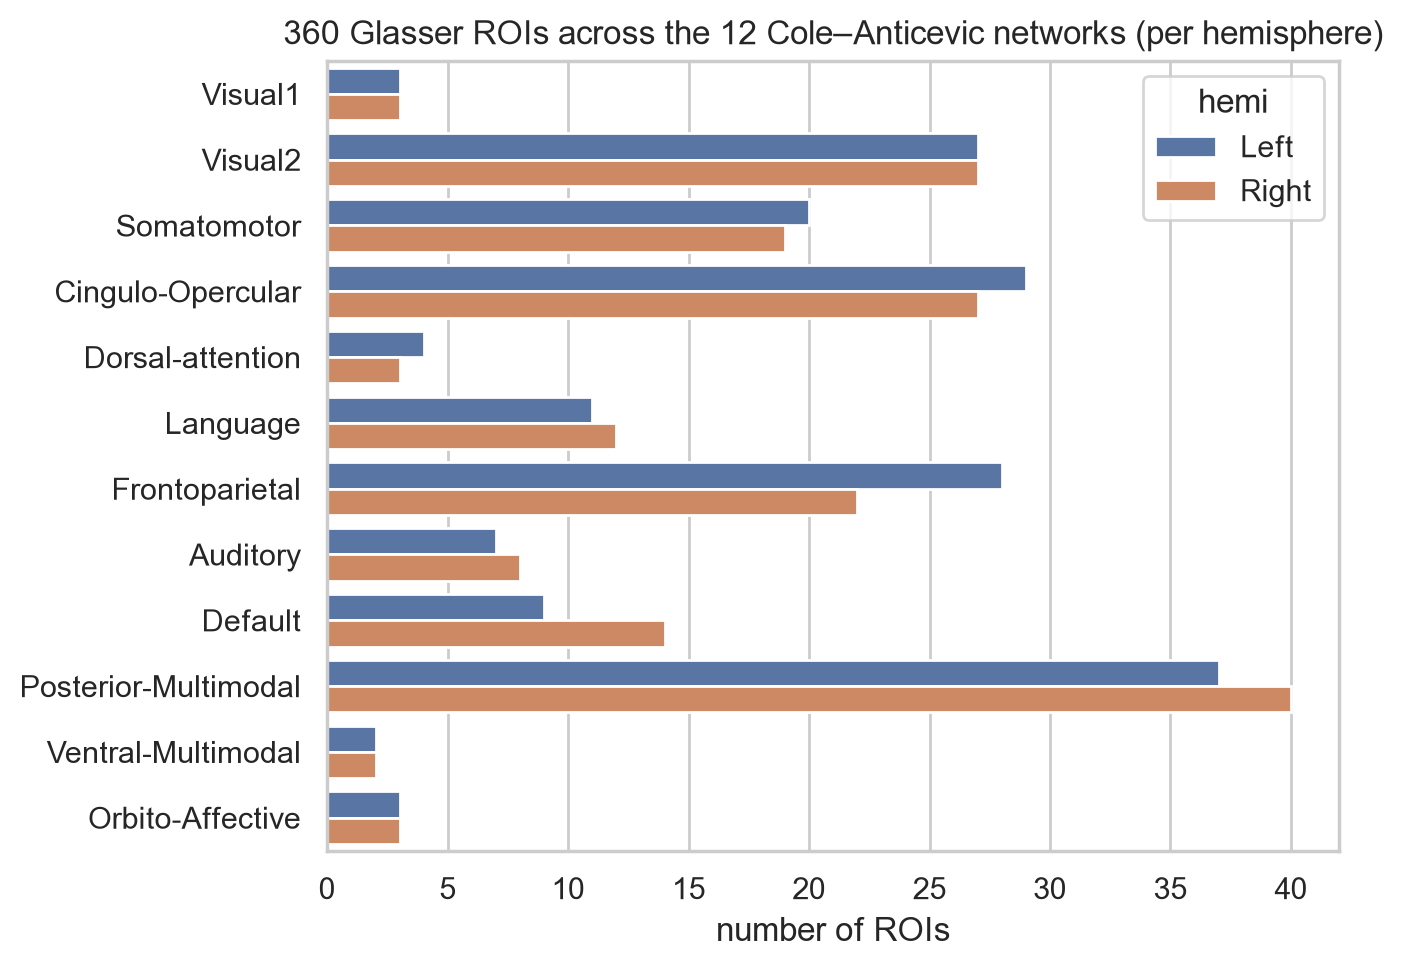

In [5]:
# Goutham's signature view: ROI count per network, split by hemisphere.
NETWORK_ORDER = [
    "Visual1", "Visual2", "Somatomotor", "Cingulo-Opercular", "Dorsal-attention",
    "Language", "Frontoparietal", "Auditory", "Default", "Posterior-Multimodal",
    "Ventral-Multimodal", "Orbito-Affective",
]
counts = regions.groupby(["network", "hemi"]).size().reset_index(name="n_rois")

plt.figure(figsize=(7, 5))
sns.barplot(data=counts, y="network", x="n_rois", hue="hemi", order=NETWORK_ORDER)
plt.xlabel("number of ROIs"); plt.ylabel("")
plt.title("360 Glasser ROIs across the 12 Cole–Anticevic networks (per hemisphere)")
plt.tight_layout(); plt.show()

The parcellation is **cortex only** — no subcortex, no cerebellum — and ROIs are matched across
hemispheres (rows 0–179 Right, 180–359 Left). The three networks the pod flagged as
task-relevant (**Frontoparietal, Default, Cingulo-Opercular / salience**) are all well represented.

### 3.2 · The BOLD signal — one subject, one run

The raw object is a `(360 ROIs × frames)` array. Let's look at one subject's WM run.

In [6]:
subj = subjects[0]
raw = ds.load_timeseries(spec, subj, run=0)     # run 0 (B: RL); mean already removed per ROI
print(f"subject {subj} · WM run 0 raw shape: {raw.shape}  → (ROIs, frames); {raw.shape[1]} frames × 0.72 s ≈ {raw.shape[1]*0.72:.0f} s")

subject 0 · WM run 0 raw shape: (360, 405)  → (ROIs, frames); 405 frames × 0.72 s ≈ 292 s


### 3.3 · Two loads from the timing files

The EV (timing) files say *when* each condition happens. `pp.condition_timeseries` reads them,
converts onsets/durations to frame indices, keeps only the frames of the requested load, and
concatenates the two runs (LR+RL). You get the BOLD **restricted to one condition**.

0-back BOLD: (360, 312)
2-back BOLD: (360, 312)
→ 156 frames/run × 2 runs = 312 frames per condition; the 0bk/2bk frame sets never overlap


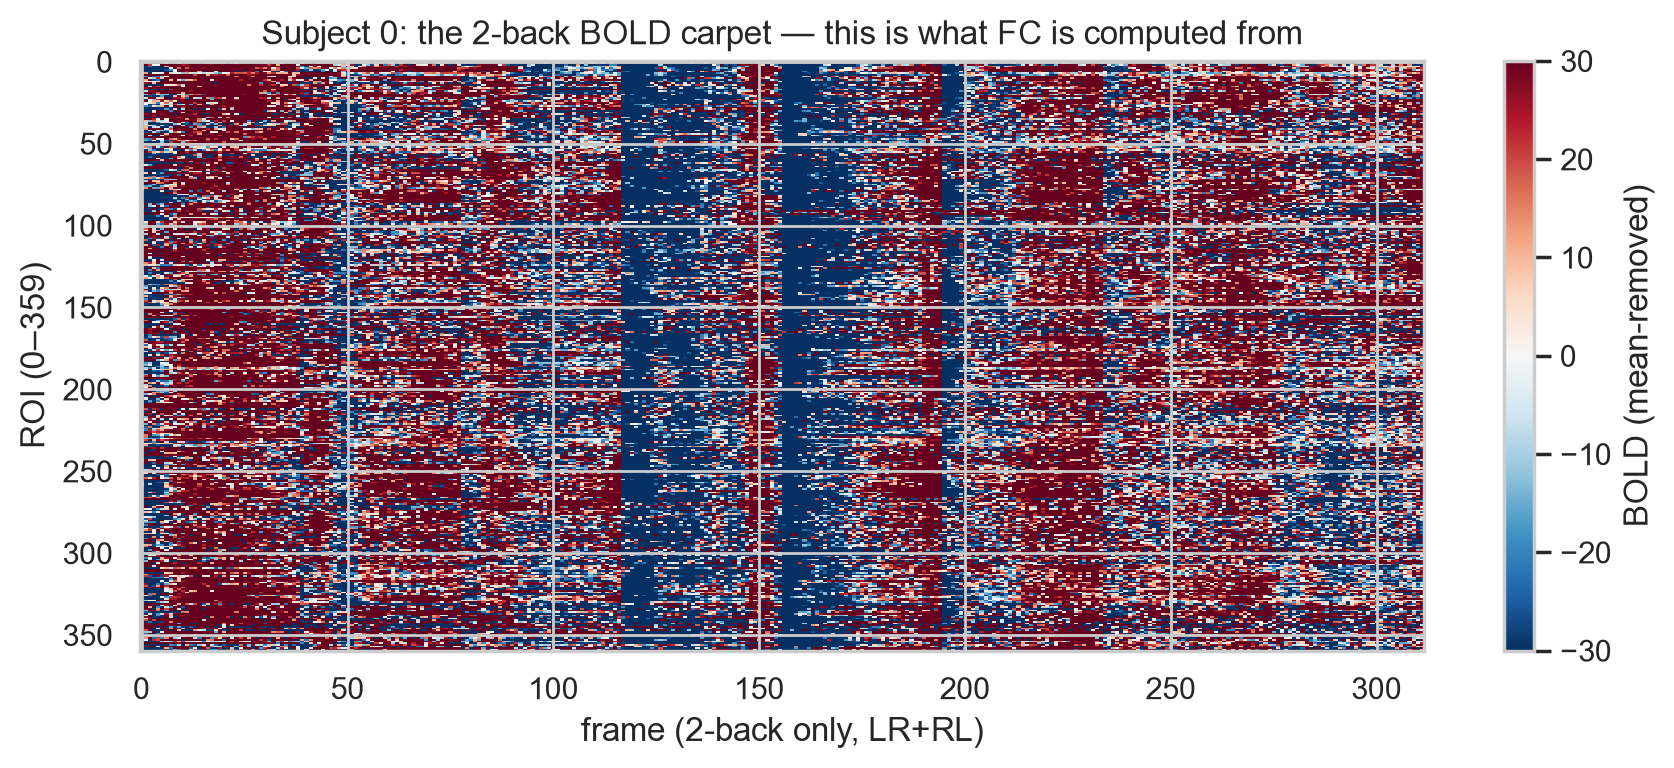

In [7]:
ts_0bk = pp.condition_timeseries(spec, subj, "0back")   # (360, 312) — both runs pooled
ts_2bk = pp.condition_timeseries(spec, subj, "2back")
print("0-back BOLD:", ts_0bk.shape)
print("2-back BOLD:", ts_2bk.shape)
print("→ 156 frames/run × 2 runs = 312 frames per condition; the 0bk/2bk frame sets never overlap")

# 'See' it: the 2-back BOLD carpet that becomes ONE connectivity matrix.
plt.figure(figsize=(9, 4))
plt.imshow(ts_2bk, aspect="auto", cmap="RdBu_r", vmin=-30, vmax=30, interpolation="nearest")
plt.colorbar(label="BOLD (mean-removed)")
plt.xlabel("frame (2-back only, LR+RL)"); plt.ylabel("ROI (0–359)")
plt.title(f"Subject {subj}: the 2-back BOLD carpet — this is what FC is computed from")
plt.tight_layout(); plt.show()

### 3.4 · The behavioural target — what we predict

`pp.behaviour_table(spec)` gives one row per subject with accuracy and reaction-time summaries.
The candidate target is **`acc_2bk`** (mean 2-back accuracy). 0-back sits near ceiling — little to
predict; 2-back is where people **differ**, so that variance is the signal.

behaviour_table (analytic): (336, 7)


,subject,acc_0bk,acc_2bk,acc_cost,rt_2bk
0,0,1.0000,0.921875,-0.078125,1054.4375
1,1,1.0000,0.968750,-0.031250,865.5625
2,2,0.9875,0.921875,-0.065625,940.5625
3,3,0.9750,0.703125,-0.271875,798.0000
4,4,0.6750,0.765625,0.090625,864.0625


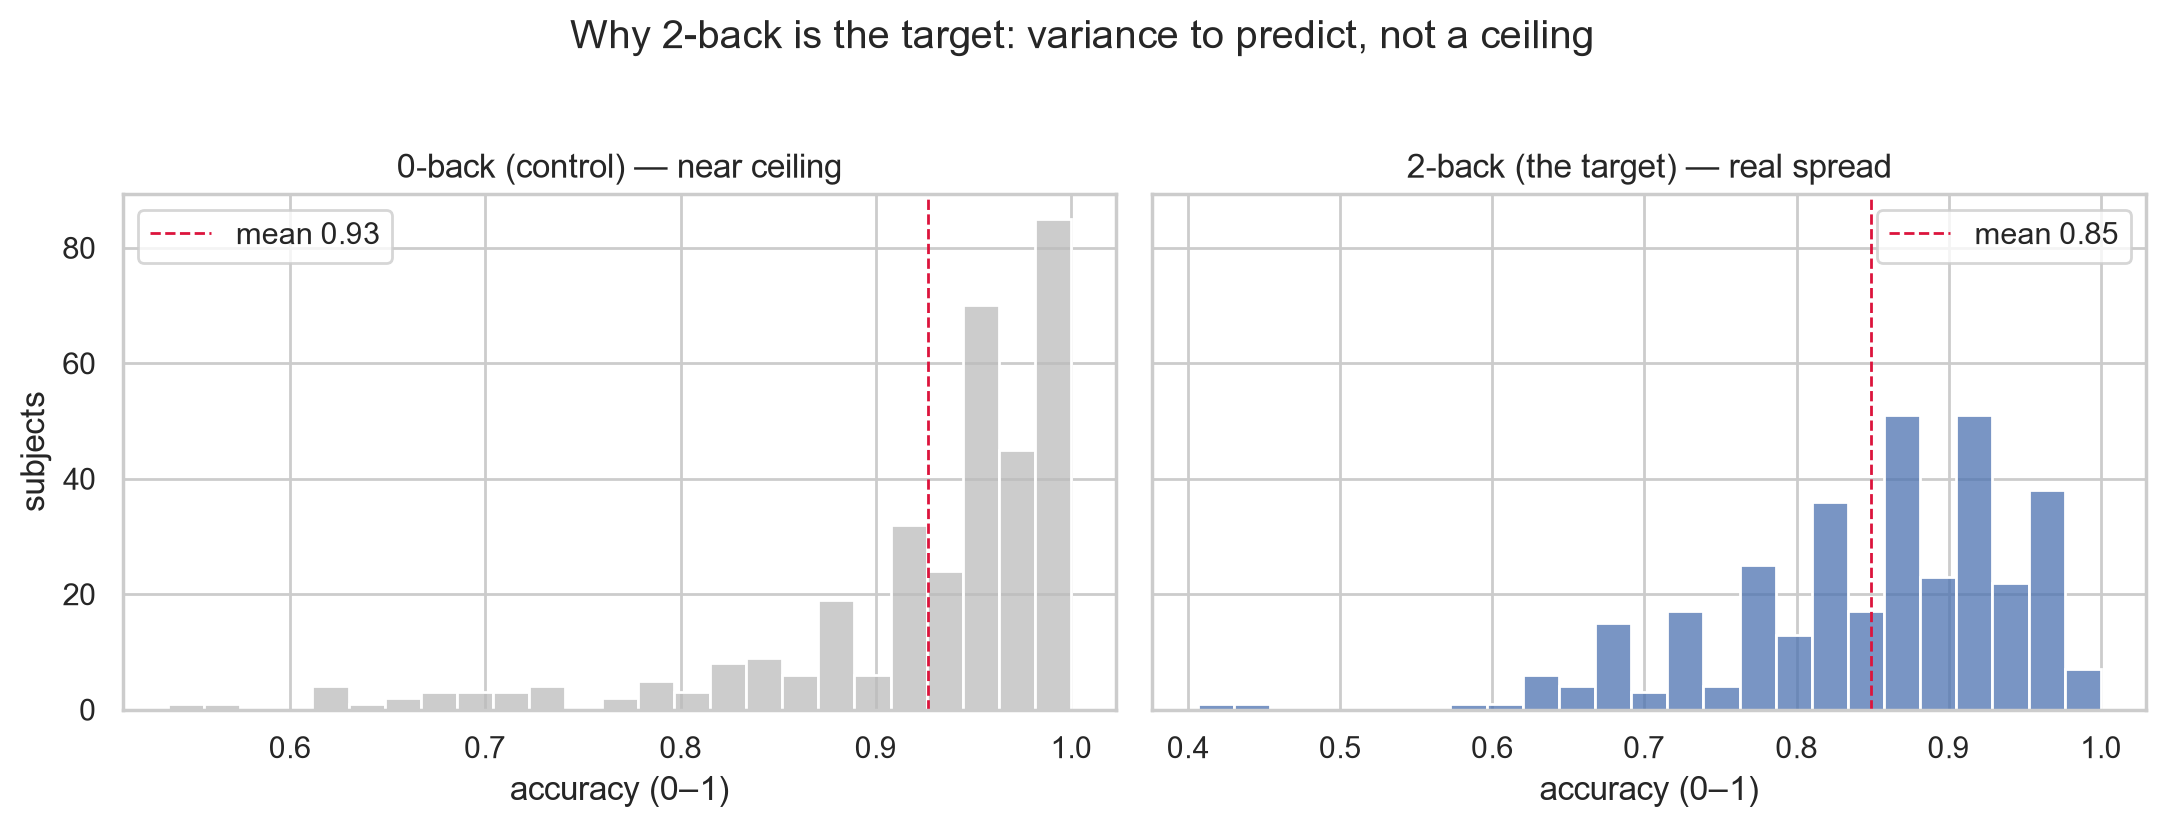

acc_2bk: mean=0.849  range=0.406–1.000


In [8]:
beh = pp.behaviour_table(spec)
beh = beh[beh["subject"].isin(subjects)].reset_index(drop=True)   # analytic cohort (336)
print("behaviour_table (analytic):", beh.shape)
display(beh[["subject", "acc_0bk", "acc_2bk", "acc_cost", "rt_2bk"]].head())

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col, title in zip(axes, ["acc_0bk", "acc_2bk"], ["0-back (control) — near ceiling", "2-back (the target) — real spread"]):
    sns.histplot(beh[col], bins=25, ax=ax, color="#4c72b0" if col == "acc_2bk" else "#bbbbbb")
    ax.axvline(beh[col].mean(), color="crimson", ls="--", lw=1, label=f"mean {beh[col].mean():.2f}")
    ax.set_title(title); ax.set_xlabel("accuracy (0–1)"); ax.legend()
axes[0].set_ylabel("subjects")
plt.suptitle("Why 2-back is the target: variance to predict, not a ceiling", y=1.03)
plt.tight_layout(); plt.show()

print(f"acc_2bk: mean={beh['acc_2bk'].mean():.3f}  range={beh['acc_2bk'].min():.3f}–{beh['acc_2bk'].max():.3f}")

> **Cleaner target available on B (not on A): d′.** Raw accuracy mixes *sensitivity* with
> *response bias*. Because B's `wm.csv` carries consistent `ACC_TARGET` / `ACC_NONTARGET`,
> we can build **hit** and **false-alarm** rates and, from them, **d′** — the signal-detection
> sensitivity Valeria proposed. `pp.signal_detection_table` returns exactly those inputs
> (A can't: its `Stats.txt` target fields are internally inconsistent — a known HCP bug).

In [9]:
sd = pp.signal_detection_table(spec)               # B only; hit = ACC_TARGET, fa = 1 - ACC_NONTARGET
sd = sd[sd["subject"].isin(subjects)].reset_index(drop=True)
print("signal_detection_table:", sd.shape)
display(sd.head())

# d' preview with a 1/(2N) boundary correction so perfect hit/zero-fa subjects don't blow up.
# N (trials per condition) is small in HCP-WM, so extreme-rate correction matters — the exact
# correction is a team decision (see hand-off). This is illustrative, not the frozen target.
from scipy.stats import norm
N_TRIALS = 30.0                                    # ~ order of 2-back target trials per subject; placeholder
def _clip(r):
    return np.clip(r, 1 / (2 * N_TRIALS), 1 - 1 / (2 * N_TRIALS))
dprime_2bk = norm.ppf(_clip(sd["hit_2bk"])) - norm.ppf(_clip(sd["fa_2bk"]))
print(f"illustrative d'(2-back): mean={np.nanmean(dprime_2bk):.2f}  range={np.nanmin(dprime_2bk):.2f}–{np.nanmax(dprime_2bk):.2f}")

signal_detection_table: (336, 5)


,subject,hit_0bk,fa_0bk,hit_2bk,fa_2bk
0,0,1.0000,0.000000,1.0000,0.104167
1,1,1.0000,0.000000,0.9375,0.020833
2,2,0.9375,0.000000,0.9375,0.083333
3,3,0.9375,0.015625,0.1250,0.104167
4,4,0.5000,0.281250,0.6250,0.187500


illustrative d'(2-back): mean=2.15  range=-1.16–4.26


## 4 · From BOLD to functional connectivity

**Functional connectivity** = how correlated two ROIs' time series are. Stack all 360 and you get a
`360 × 360` matrix per condition. This is Goutham's `connect_dots`: **Pearson correlation is exactly
z-scoring each ROI over time and averaging their dot product** — which is what `np.corrcoef` does.

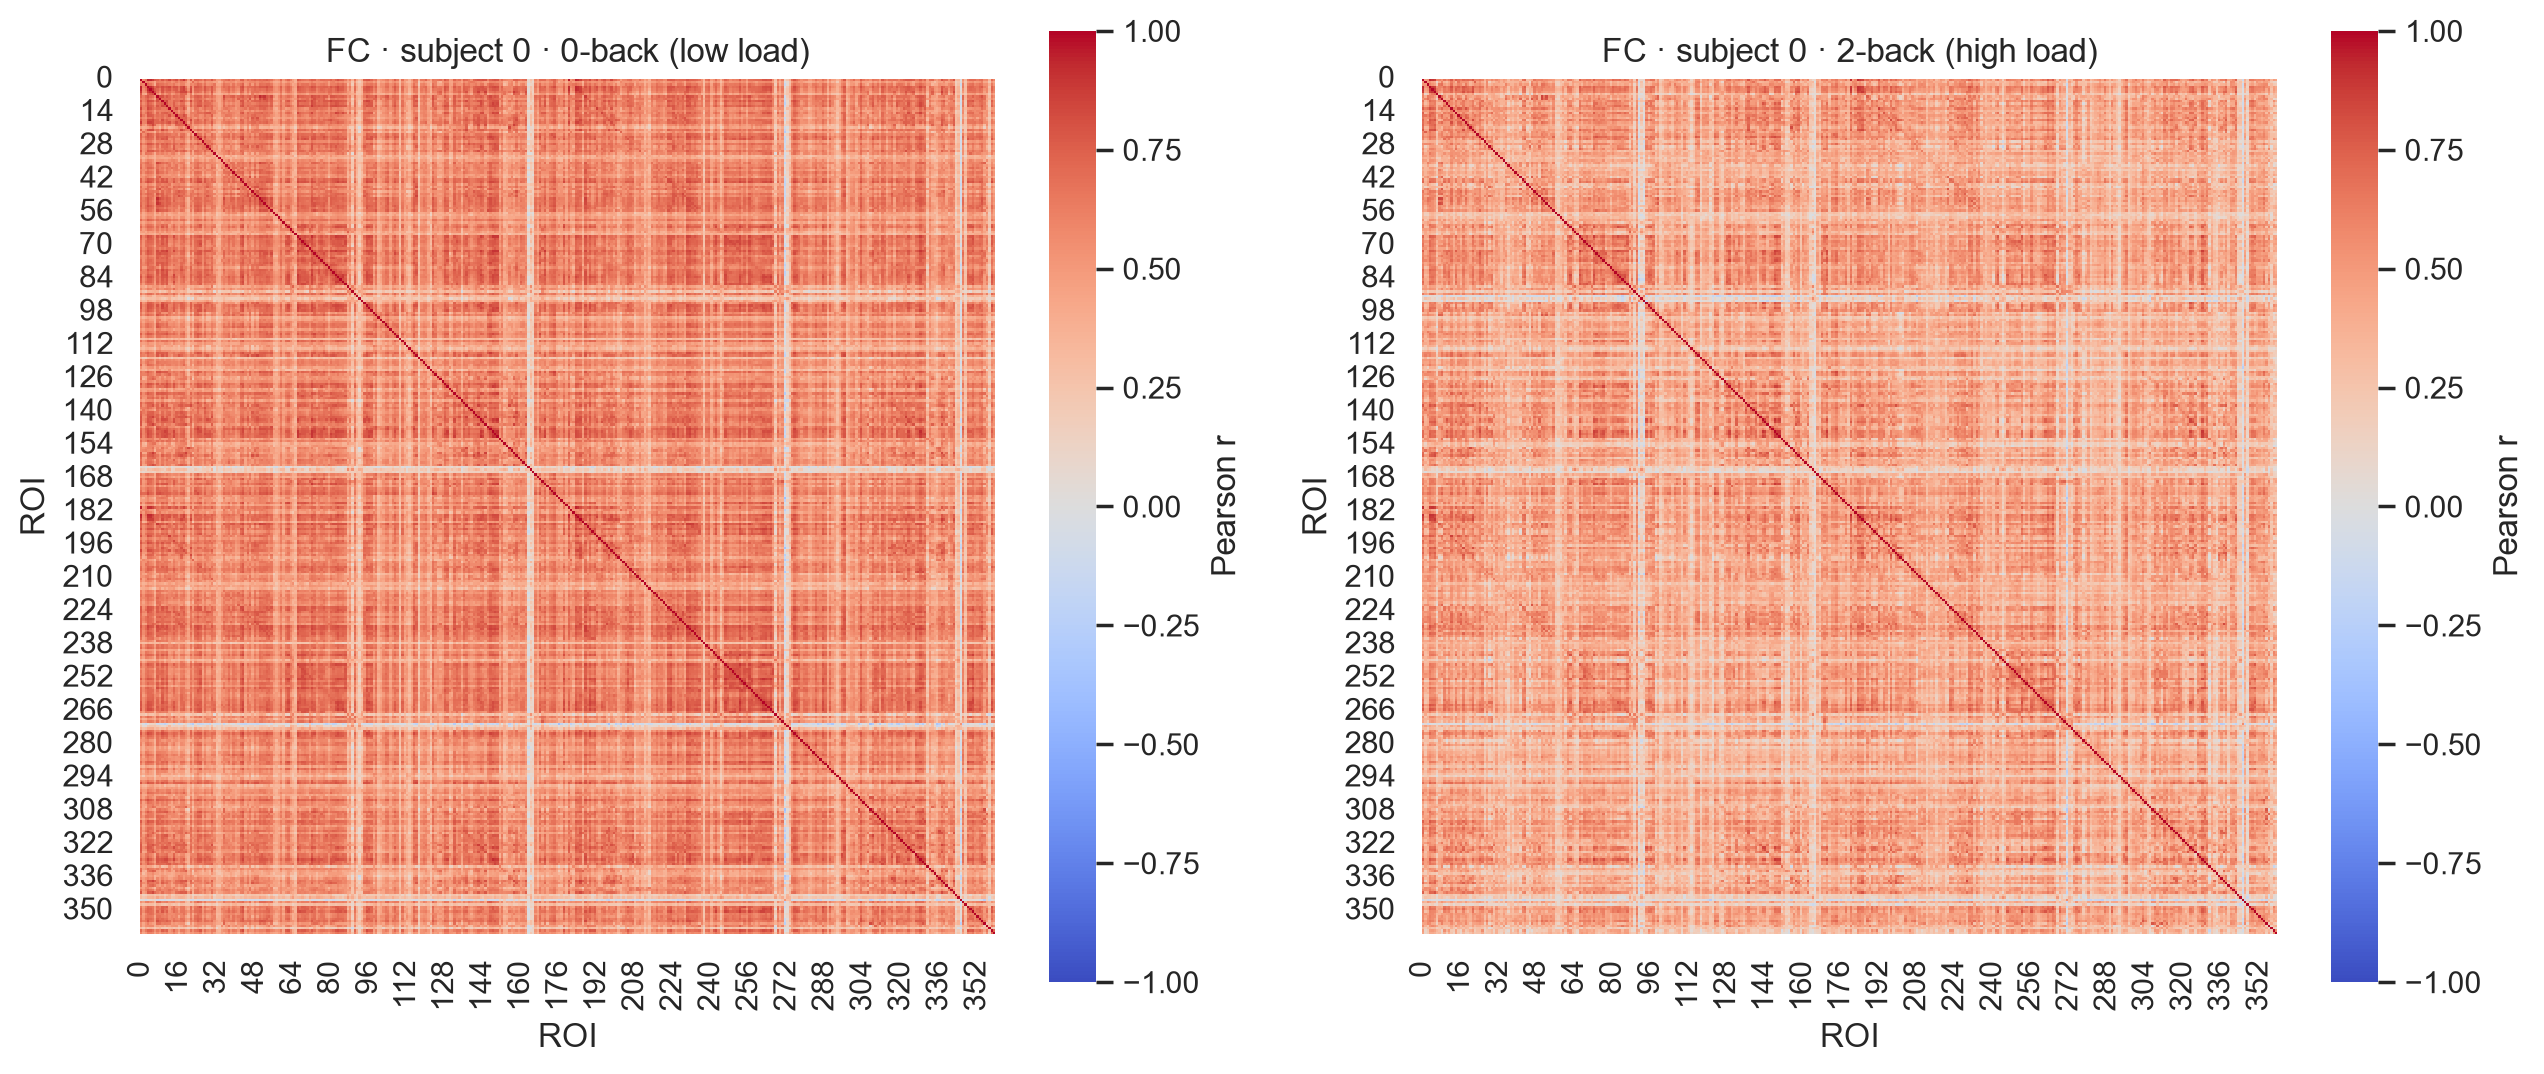

In [10]:
def connect_dots(bold):
    # FC matrix for one condition: Pearson corr across ROIs over the time axis -> (360, 360).
    return np.corrcoef(bold)

fc_0bk = connect_dots(ts_0bk)      # calm mind
fc_2bk = connect_dots(ts_2bk)      # busy mind

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, fc, name in zip(axes, [fc_0bk, fc_2bk], ["0-back (low load)", "2-back (high load)"]):
    sns.heatmap(fc, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
                cbar_kws={"label": "Pearson r"}, ax=ax)
    ax.set_title(f"FC · subject {subj} · {name}"); ax.set_xlabel("ROI"); ax.set_ylabel("ROI")
plt.tight_layout(); plt.show()

The **reconfiguration** is the difference of the two matrices — Goutham's `brain_shift =
busy_net − calm_net`. Red = a pair got *more* connected under load; blue = *less*.

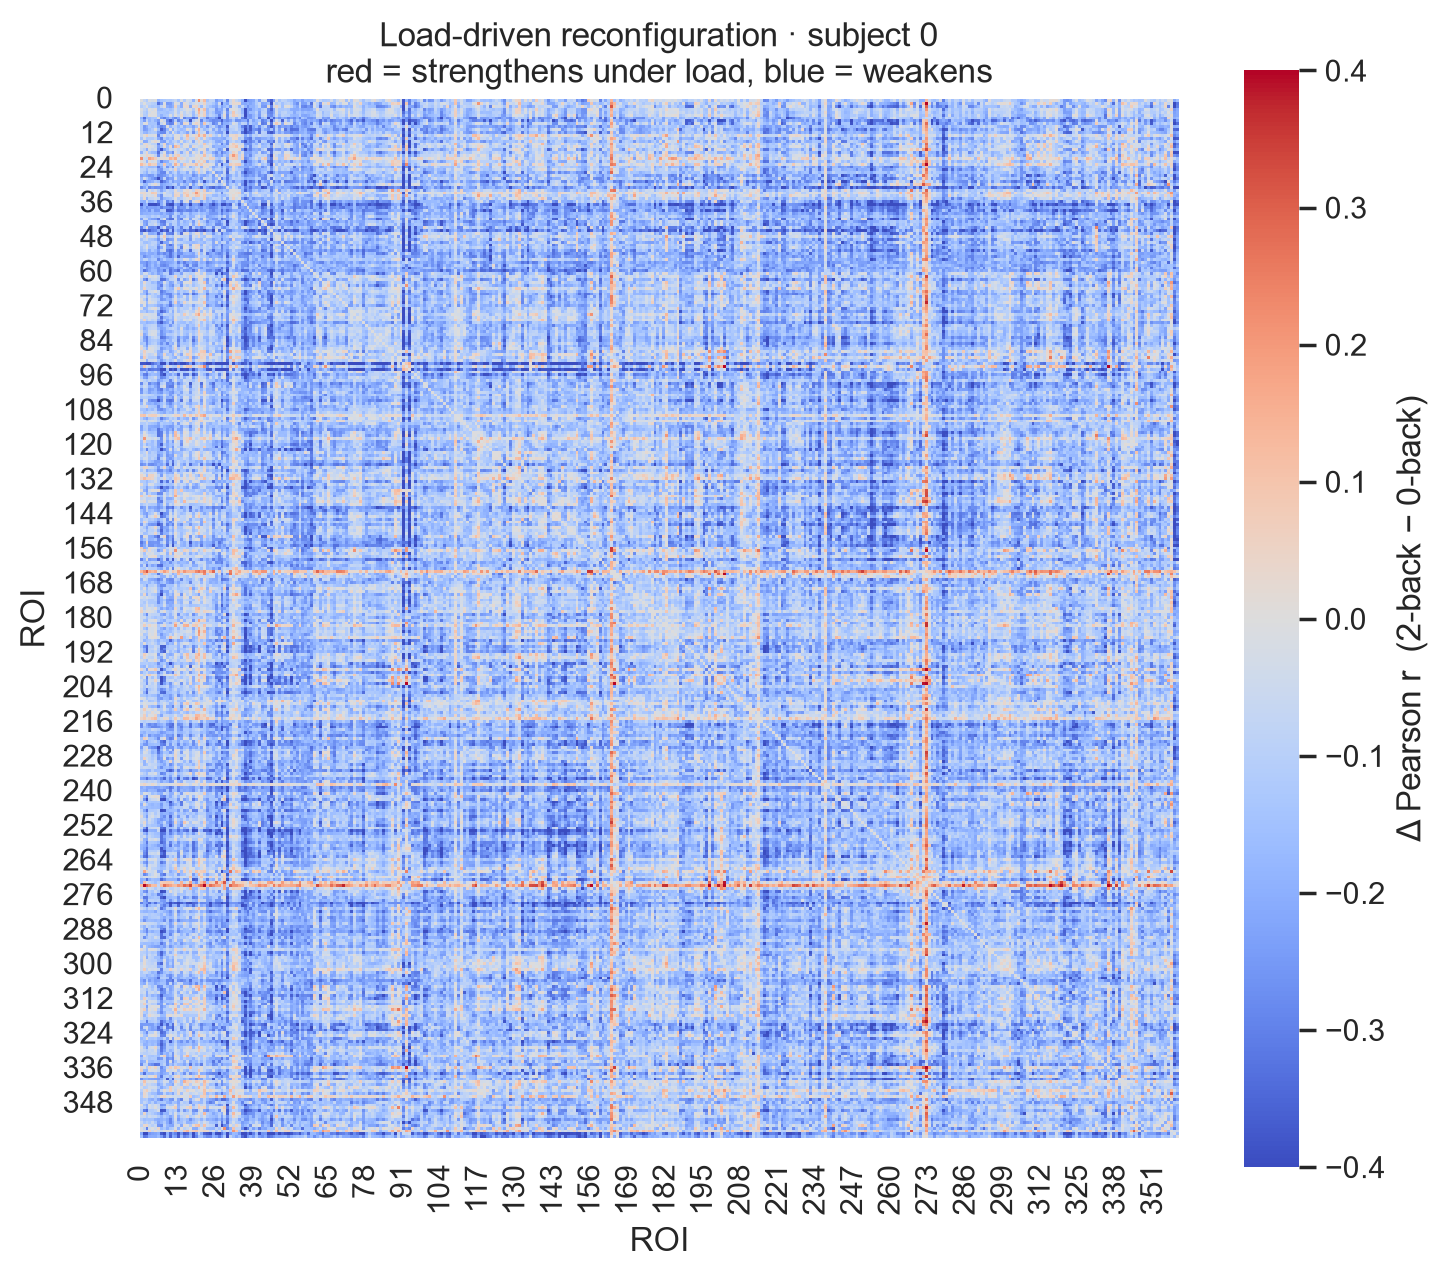

mean |Δ| over ROI pairs: 0.151


In [11]:
brain_shift = fc_2bk - fc_0bk            # the object the hypothesis is about
lim = 0.4
plt.figure(figsize=(7.5, 6.5))
sns.heatmap(brain_shift, cmap="coolwarm", center=0, vmin=-lim, vmax=lim, square=True,
            cbar_kws={"label": "Δ Pearson r  (2-back − 0-back)"})
plt.title(f"Load-driven reconfiguration · subject {subj}\nred = strengthens under load, blue = weakens")
plt.xlabel("ROI"); plt.ylabel("ROI")
plt.tight_layout(); plt.show()
print(f"mean |Δ| over ROI pairs: {np.abs(brain_shift)[np.triu_indices(360, 1)].mean():.3f}")

## 5 · Does the brain reconfigure with load? — a group preview

One subject is noisy. Let's average the reconfiguration over a **sample of subjects** and collapse
the `360 × 360` ROI matrix into a **`12 × 12` network matrix** (Goutham's "societies" fingerprint) —
readable at a glance. This is the project's central signal, previewed.

> Sample = `N_DEMO` subjects to keep re-runs fast; bump to `len(subjects)` for the full cohort.

In [12]:
N_DEMO = 40
sample = subjects[:N_DEMO]

net = regions["network"].to_numpy()
net_idx = {nw: np.where(net == nw)[0] for nw in NETWORK_ORDER}

def to_network_matrix(roi_mat):
    # Average a 360x360 ROI matrix into a 12x12 network-by-network matrix (canonical order).
    K = len(NETWORK_ORDER)
    out = np.zeros((K, K))
    for i, a in enumerate(NETWORK_ORDER):
        for j, b in enumerate(NETWORK_ORDER):
            out[i, j] = roi_mat[np.ix_(net_idx[a], net_idx[b])].mean()
    return out

shift_stack = []
for s in sample:
    d0 = connect_dots(pp.condition_timeseries(spec, s, "0back"))
    d2 = connect_dots(pp.condition_timeseries(spec, s, "2back"))
    shift_stack.append(to_network_matrix(d2 - d0))
group_shift = np.mean(shift_stack, axis=0)
print(f"averaged reconfiguration over {len(sample)} subjects → {group_shift.shape} network matrix")

averaged reconfiguration over 40 subjects → (12, 12) network matrix


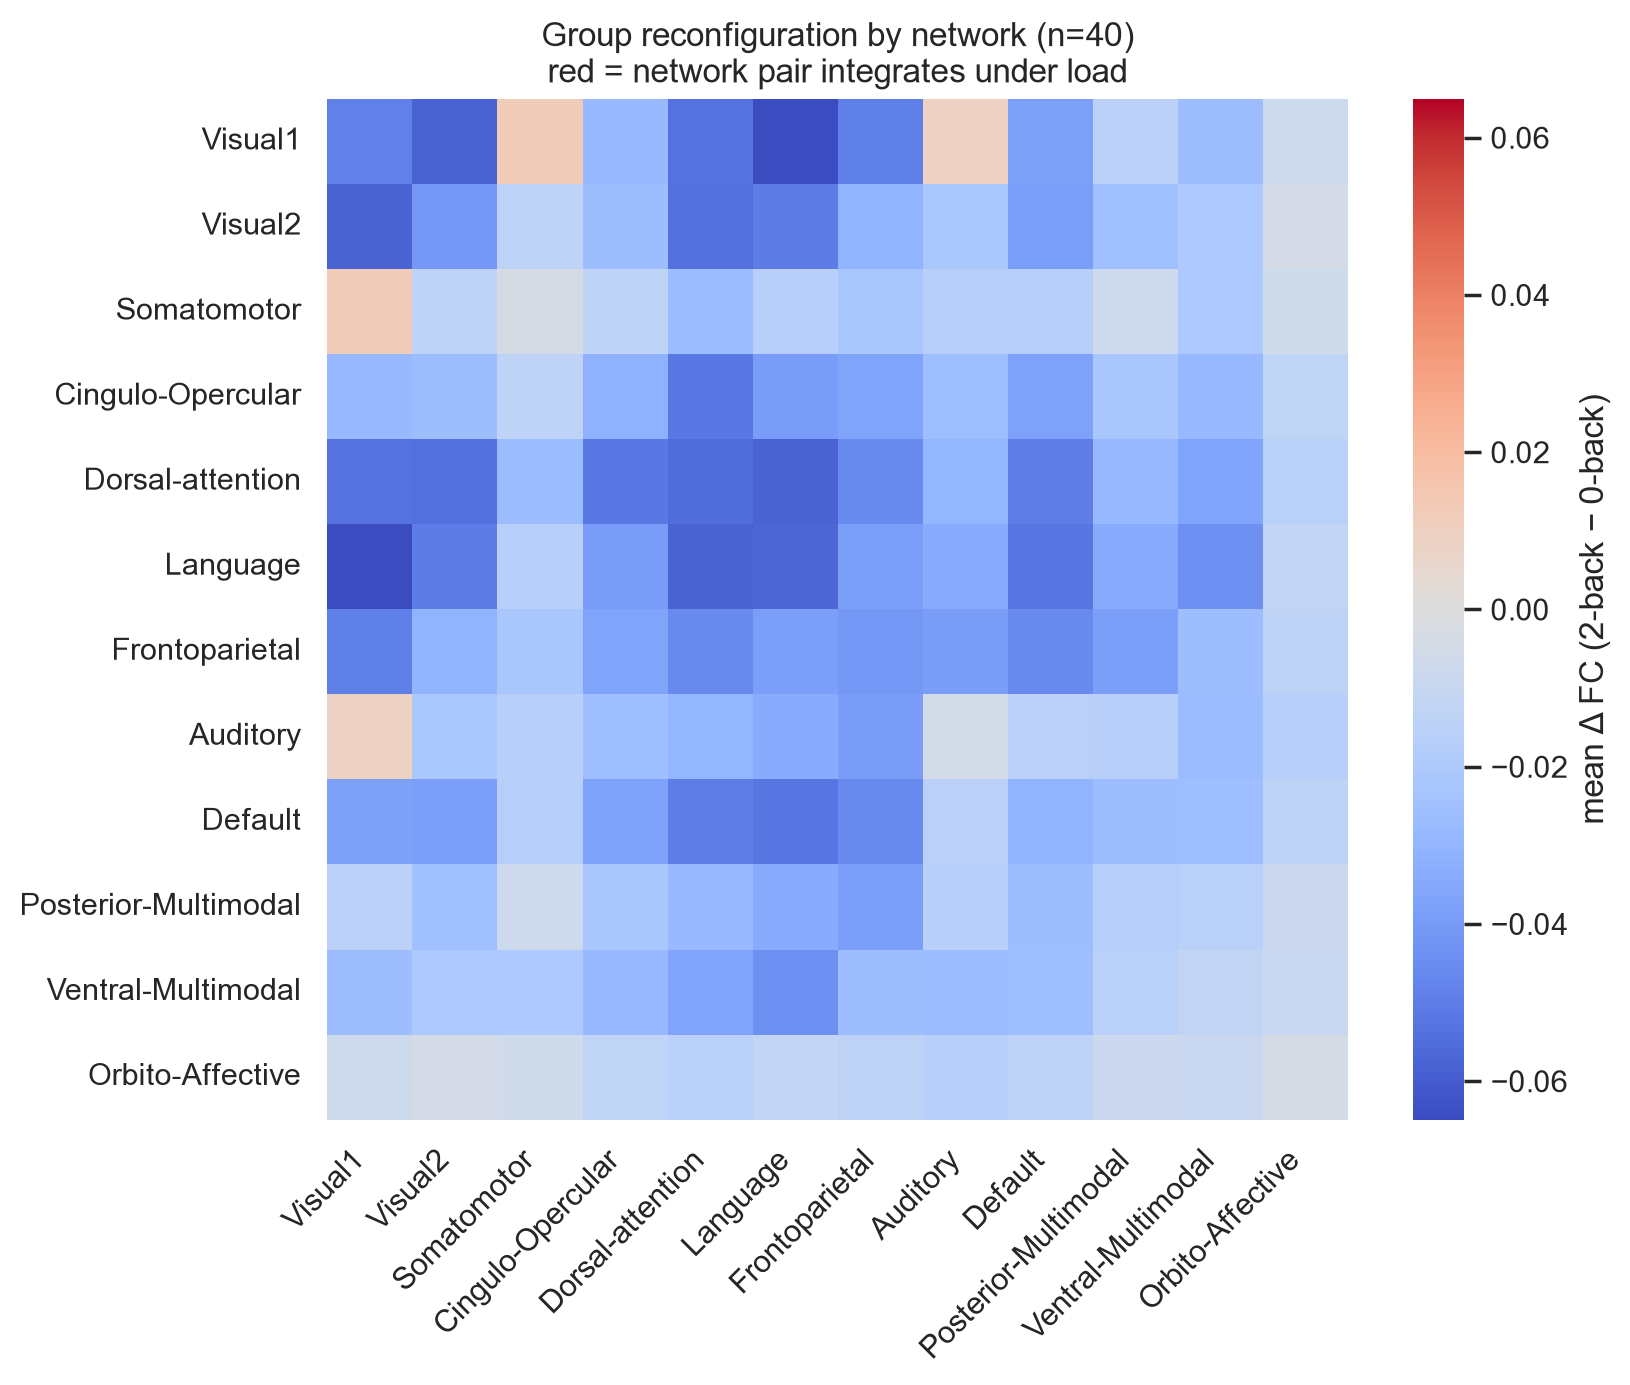

In [13]:
lim = np.abs(group_shift).max()
plt.figure(figsize=(8.5, 7))
sns.heatmap(group_shift, cmap="coolwarm", center=0, vmin=-lim, vmax=lim, square=True,
            xticklabels=NETWORK_ORDER, yticklabels=NETWORK_ORDER,
            cbar_kws={"label": "mean Δ FC (2-back − 0-back)"})
plt.title(f"Group reconfiguration by network (n={len(sample)})\nred = network pair integrates under load")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

### Segregation vs integration — the hypothesis, in one number

Arefeh's proposed hypothesis: under load the brain shifts from **segregation** (strong
*within*-network coupling) toward **integration** (stronger *between*-network coupling). The
`12 × 12` matrix answers it directly: **diagonal = within-network** change, **off-diagonal =
between-network** change.

mean Δ within-network  (segregation axis): -0.0290
mean Δ between-network (integration axis): -0.0277
→ between > within: connectivity integrates under load — the hypothesis direction


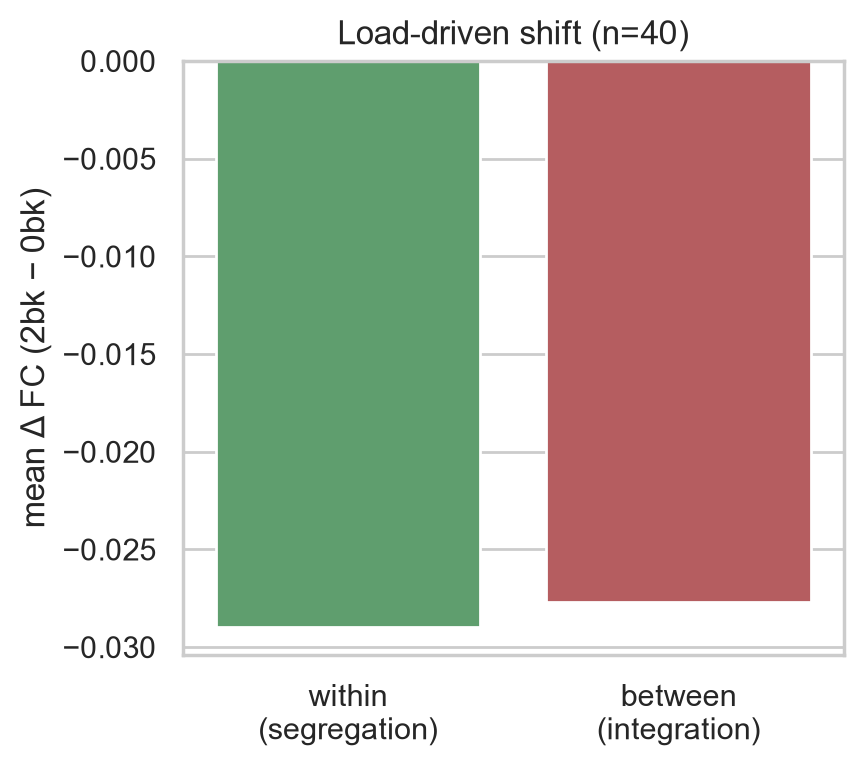

In [14]:
K = len(NETWORK_ORDER)
diag = np.eye(K, dtype=bool)
within = group_shift[diag].mean()
between = group_shift[~diag].mean()
print(f"mean Δ within-network  (segregation axis): {within:+.4f}")
print(f"mean Δ between-network (integration axis): {between:+.4f}")
if between > within:
    print("→ between > within: connectivity integrates under load — the hypothesis direction")
else:
    print("→ no net integration shift in this 40-subject average; the signal is pair-specific "
          "(read it off the matrix above, e.g. Frontoparietal ↔ Default), not the global mean")

labels = ["within\n(segregation)", "between\n(integration)"]
plt.figure(figsize=(4.5, 4))
sns.barplot(x=labels, y=[within, between], hue=labels,
            palette=["#55a868", "#c44e52"], legend=False)
plt.axhline(0, color="k", lw=0.8); plt.ylabel("mean Δ FC (2bk − 0bk)")
plt.title(f"Load-driven shift (n={len(sample)})")
plt.tight_layout(); plt.show()

*Read with care:* this is a small sample and a descriptive average — a direction to test, **not**
a result. The real test (per the Project TA) is **prediction on held-out subjects**, next.

## 6 · The prediction target + a leakage-safe split

The Project TA's north star: **predict working-memory performance on subjects the model never
saw**. `ev.make_split` splits **by subject** (never by frame/run) into train/test + CV folds, so
no one leaks across the boundary.

In [15]:
split = ev.make_split(spec)
print("split by SUBJECT (leakage-safe):")
print(f"  total analytic : {split['n_total']}")
print(f"  train / test   : {split['n_train']} / {split['n_test']}  (test_frac={split['test_frac']})")
print(f"  CV folds        : {split['cv_folds']} over the train set")
print(f"  no overlap?     : {set(split['train']).isdisjoint(split['test'])}")

split by SUBJECT (leakage-safe):
  total analytic : 336
  train / test   : 269 / 67  (test_frac=0.2)
  CV folds        : 5 over the train set
  no overlap?     : True


## 7 · Where your step plugs in — hand-off

**What this produced.** A guided tour of Finalist B and the two project inputs, all through the
shared layer — no loaders re-written:

| Object | Call | Shape / form |
|---|---|---|
| Analytic cohort | `ds.load_subjects(spec)` | 336 pseudo-IDs |
| ROI → network table | `pp.region_table(spec)` | 360 × 5 |
| BOLD per condition | `pp.condition_timeseries(spec, s, "2back")` | (360, 312) |
| FC per condition | `np.corrcoef(...)` | (360, 360) |
| Behavioural target | `pp.behaviour_table(spec)` → `acc_2bk` | 336 × 7 |
| d′ inputs (B only) | `pp.signal_detection_table(spec)` | hit / fa |
| Leakage-safe split | `ev.make_split(spec)` | by subject |

**Your entry point:**
- **FC (Valeria · Arefeh)** — consume `condition_timeseries`; you own the FC estimation choices.
- **Graphs (Goutham)** — threshold the FC / reconfiguration matrices into weighted, undirected graphs.
- **Graph metrics (Kerem · Arefeh)** — segregation / integration on those graphs.
- **Prediction (Valeria · Arefeh)** — features → `acc_2bk` (or d′) on `split`'s held-out subjects.

**What the team still decides (open):**
- **Target:** `acc_2bk` vs **d′** (and, if d′, the extreme-rate correction — the `1/(2N)` above is a placeholder).
- **HRF lag:** Goutham's POC shifts EV onsets by ~4 s before selecting frames; the shared
  `condition_timeseries` does not. Worth reconciling — it changes which frames enter FC.
- **FC/graph choices:** thresholding, negative edges, level of aggregation.

**Caveats.** Cortex-only parcellation (no subcortex/cerebellum). `acc_2bk` is a bounded proportion
with a ceiling (consider a logit transform when modelling). The group preview here is a 40-subject
descriptive average, not a test.